In [6]:
#before running this please change the RUNTIME to GPU (Runtime -> Change runtime type -> set harware accelarotor as GPU)
#Mount our google drive
# from google.colab import drive
# drive.mount('/content/drive')

In [7]:
#import libraries
# !pip3 install face_recognition

import torch
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader
from torch.utils.data.dataset import Dataset
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import face_recognition

In [8]:
#import libraries
import torch
from torch.autograd import Variable
import time
import os
import sys
import os
from torch import nn
from torchvision import models

In [9]:
#Model with feature visualization
from torch import nn
from torchvision import models
class Model(nn.Module):
    def __init__(self, num_classes,latent_dim= 2048, lstm_layers=1 , hidden_dim = 2048, bidirectional = False):
        super(Model, self).__init__()
        model = models.resnext50_32x4d(pretrained = True)
        self.model = nn.Sequential(*list(model.children())[:-2])
        self.lstm = nn.LSTM(latent_dim,hidden_dim, lstm_layers,  bidirectional)
        self.relu = nn.LeakyReLU()
        self.dp = nn.Dropout(0.4)
        self.linear1 = nn.Linear(2048,num_classes)
        self.avgpool = nn.AdaptiveAvgPool2d(1)
    def forward(self, x):
        batch_size,seq_length, c, h, w = x.shape
        x = x.view(batch_size * seq_length, c, h, w)
        fmap = self.model(x)
        x = self.avgpool(fmap)
        x = x.view(batch_size,seq_length,2048)
        x_lstm,_ = self.lstm(x,None)
        return fmap,self.dp(self.linear1(x_lstm[:,-1,:]))

In [10]:
im_size = 112
mean=[0.485, 0.456, 0.406]
std=[0.229, 0.224, 0.225]
sm = nn.Softmax()
inv_normalize =  transforms.Normalize(mean=-1*np.divide(mean,std),std=np.divide([1,1,1],std))
def im_convert(tensor):
    """ Display a tensor as an image. """
    image = tensor.to("cpu").clone().detach()
    image = image.squeeze()
    image = inv_normalize(image)
    image = image.numpy()
    image = image.transpose(1,2,0)
    image = image.clip(0, 1)
    cv2.imwrite('./2.png',image*255)
    return image

def predict(model,img,path = './'):
  fmap, logits = model(img.to(device))
  params = list(model.parameters())
  weight_softmax = model.linear1.weight.detach().cpu().numpy()
  logits = sm(logits)
  _,prediction = torch.max(logits,1)
  confidence = logits[:,int(prediction.item())].item()*100
  print('confidence of prediction:',logits[:,int(prediction.item())].item()*100)
  idx = np.argmax(logits.detach().cpu().numpy())
  bz, nc, h, w = fmap.shape
  out = np.dot(fmap[-1].detach().cpu().numpy().reshape((nc, h*w)).T,weight_softmax[idx,:].T)
  predict = out.reshape(h,w)
  predict = predict - np.min(predict)
  predict_img = predict / np.max(predict)
  predict_img = np.uint8(255*predict_img)
  out = cv2.resize(predict_img, (im_size,im_size))
  heatmap = cv2.applyColorMap(out, cv2.COLORMAP_JET)
  img = im_convert(img[:,-1,:,:,:])
  result = heatmap * 0.5 + img*0.8*255
  cv2.imwrite('/content/1.png',result)
  result1 = heatmap * 0.5/255 + img*0.8
  r,g,b = cv2.split(result1)
  result1 = cv2.merge((r,g,b))
  plt.imshow(result1)
  plt.show()
  return [int(prediction.item()),confidence]
#img = train_data[100][0].unsqueeze(0)
#predict(model,img)

In [11]:
#!pip3 install face_recognition
import torch
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader
from torch.utils.data.dataset import Dataset
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import face_recognition
class validation_dataset(Dataset):
    def __init__(self,video_names,sequence_length = 60,transform = None):
        self.video_names = video_names
        self.transform = transform
        self.count = sequence_length
    def __len__(self):
        return len(self.video_names)
    def __getitem__(self,idx):
        video_path = self.video_names[idx]
        frames = []
        a = int(100/self.count)
        first_frame = np.random.randint(0,a)      
        for i,frame in enumerate(self.frame_extract(video_path)):
            #if(i % a == first_frame):
            faces = face_recognition.face_locations(frame)
            try:
              top,right,bottom,left = faces[0]
              frame = frame[top:bottom,left:right,:]
            except:
              pass
            frames.append(self.transform(frame))
            if(len(frames) == self.count):
              break
        #print("no of frames",len(frames))
        frames = torch.stack(frames)
        frames = frames[:self.count]
        return frames.unsqueeze(0)
    def frame_extract(self,path):
      vidObj = cv2.VideoCapture(path) 
      success = 1
      while success:
          success, image = vidObj.read()
          if success:
              yield image
def im_plot(tensor):
    image = tensor.cpu().numpy().transpose(1,2,0)
    b,g,r = cv2.split(image)
    image = cv2.merge((r,g,b))
    image = image*[0.22803, 0.22145, 0.216989] +  [0.43216, 0.394666, 0.37645]
    image = image*255.0
    plt.imshow(image.astype(int))
    plt.show()

Using device: mps


/Users/v/deepfake-env/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/v/deepfake-env/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNeXt50_32X4D_Weights.IMAGENET1K_V1`. You can also use `weights=ResNeXt50_32X4D_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


/Users/v/Deepfake_detection_using_deep_learning/Model Creation/dataset/Fake/id57_id56_0004.mp4


/Users/v/deepfake-env/lib/python3.11/site-packages/torch/nn/modules/module.py:1778: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)
[ WARN:0@520.445] global loadsave.cpp:1089 imwrite_ Unsupported depth image for selected encoder is fallbacked to CV_8U.
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.100392185151577..1.2341176867485046].


confidence of prediction: 99.30928945541382


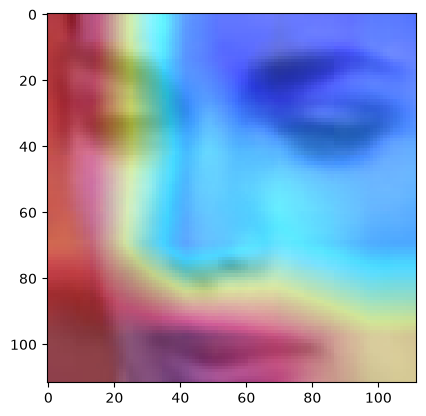

FAKE
/Users/v/Deepfake_detection_using_deep_learning/Model Creation/dataset/Real/id51_0004.mp4


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.018823526799678802..1.124313771724701].


confidence of prediction: 54.86776828765869


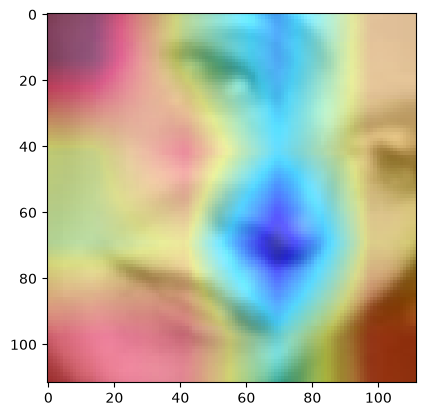

FAKE


In [12]:
# #Code for making prediction
# im_size = 112
# mean=[0.485, 0.456, 0.406]
# std=[0.229, 0.224, 0.225]

# train_transforms = transforms.Compose([
#                                         transforms.ToPILImage(),
#                                         transforms.Resize((im_size,im_size)),
#                                         transforms.ToTensor(),
#                                         transforms.Normalize(mean,std)])
# path_to_videos = ['/content/drive/My Drive/Balanced_Face_only_data/aagfhgtpmv.mp4',
#                                    '/content/drive/My Drive/Balanced_Face_only_data/aczrgyricp.mp4',
#                                    '/content/drive/My Drive/Balanced_Face_only_data/agdkmztvby.mp4',
#                                    '/content/drive/My Drive/Balanced_Face_only_data/abarnvbtwb.mp4']

# path_to_videos = ['/content/drive/My Drive/Youtube_Face_only_data/000_003.mp4',
#                   '/content/drive/My Drive/Youtube_Face_only_data/000.mp4',
#                   '/content/drive/My Drive/Youtube_Face_only_data/002_006.mp4',
#                   '/content/drive/My Drive/Youtube_Face_only_data/002.mp4'
                  

# ]

# path_to_videos= ["/content/drive/My Drive/DFDC_REAL_Face_only_data/aabqyygbaa.mp4"]

# video_dataset = validation_dataset(path_to_videos,sequence_length = 20,transform = train_transforms)
# model = Model(2).cuda()
# path_to_model = '/content/drive/My Drive/Models/model_87_acc_20_frames_final_data.pt'
# model.load_state_dict(torch.load(path_to_model))
# model.eval()
# for i in range(0,len(path_to_videos)):
#   print(path_to_videos[i])
#   prediction = predict(model,video_dataset[i],'./')
#   if prediction[0] == 1:
#     print("REAL")
#   else:
#     print("FAKE")

#Code for making prediction
im_size = 112
mean=[0.485, 0.456, 0.406]
std=[0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((im_size,im_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean,std)])

# device block
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

# test with one fake and one real video from your dataset
path_to_videos = [
    "/Users/v/Deepfake_detection_using_deep_learning/Model Creation/dataset/Fake/id57_id56_0004.mp4",
    "/Users/v/Deepfake_detection_using_deep_learning/Model Creation/dataset/Real/id51_0004.mp4"
]

video_dataset = validation_dataset(path_to_videos, sequence_length=20, transform=train_transforms)

model = Model(2).to(device)
path_to_model = '/Users/v/Deepfake_detection_using_deep_learning/Model Creation/checkpoint.pt'
model.load_state_dict(torch.load(path_to_model, map_location=device))
model.eval()

for i in range(0, len(path_to_videos)):
    print(path_to_videos[i])
    prediction = predict(model, video_dataset[i], './')
    if prediction[0] == 1:
        print("REAL")
    else:
        print("FAKE")

In [13]:
#Optional : If you want to pass full frame for prediction instead of face cropped frame
#code for full frame processing
class validation_dataset(Dataset):
    def __init__(self,video_names,sequence_length = 60,transform = None):
        self.video_names = video_names
        self.transform = transform
        self.count = sequence_length
    def __len__(self):
        return len(self.video_names)
    def __getitem__(self,idx):
        video_path = self.video_names[idx]
        frames = []
        a = int(100/self.count)
        first_frame = np.random.randint(0,a) 
        for i,frame in enumerate(self.frame_extract(video_path)):
          frames.append(self.transform(frame))
          if(len(frames) == self.count):
            break
        frames = torch.stack(frames)
        frames = frames[:self.count]
        return frames.unsqueeze(0)
    def frame_extract(self,path):
      vidObj = cv2.VideoCapture(path) 
      success = 1
      while success:
          success, image = vidObj.read()
          if success:
              yield image